Homework 5
====================
ASEN 5264 Decision Making Under Uncertainty  
Cavlin Henggeler

In [1]:
using DMUStudent.HW5: HW5, mc
using QuickPOMDPs: QuickPOMDP
using POMDPTools: Deterministic, Uniform, SparseCat, FunctionPolicy, RolloutSimulator
using Statistics: mean
import POMDPs

### Problem 1

In [2]:
cancer = QuickPOMDP(
    states = [:HEALTHY, :INSITU, :INVASIVE, :DEATH],
    actions = [:wait, :test, :treat],
    observations = [:pos, :neg],

    # transition should be a function that takes in s and a and returns the distribution of s'
    # state stays the same except with the following probabilities:
    # ----------------------------------------
    #    s          a       s':T(s'|s,a)
    # ----------------------------------------
    #  healthy      all     in_situ: 2%
    #  in_situ      treat   healthy: 60%
    #  in_situ      else    invasive: 10%
    #  invasive     treat   healthy: 20%, dealth: 20%
    #  invasive     else    death: 60%
    # ----------------------------------------
    transition = function (s, a)
        if s == :HEALTHY
            return SparseCat([:HEALTHY, :INSITU, :INVASIVE, :DEATH], [0.98, 0.02, 0.0, 0.0])
        elseif s == :INSITU
            if a == :treat
                return SparseCat([:HEALTHY, :INSITU, :INVASIVE, :DEATH], [0.6, 0.4, 0.0, 0.0])
            else
                return SparseCat([:HEALTHY, :INSITU, :INVASIVE, :DEATH], [0.0, 0.9, 0.1, 0.0])
            end
        elseif s == :INVASIVE
            if a == :treat
                return SparseCat([:HEALTHY, :INSITU, :INVASIVE, :DEATH], [0.2, 0.0, 0.6, 0.2])
            else
                return SparseCat([:HEALTHY, :INSITU, :INVASIVE, :DEATH], [0.0, 0.0, 0.4, 0.6])
            end
        else
            return Deterministic(s)
        end
    end,

    # observation should be a function that takes in s, a, and sp, and returns the distribution of o
    # Observation is NEGATIVE except with the following probabilities:
    # ----------------------------------------
    #    a       s'                 o:Z(o|a,s')
    # ----------------------------------------
    #  test      healthy            pos: 5%
    #  test      in-situ            pos: 80%
    #  test      invasive           pos: 100%
    #  treat     in-situ,invasive   pos: 100%
    # ----------------------------------------
    observation = function (s, a, sp)
        if a == :test
            if sp == :HEALTHY
                return SparseCat([:pos, :neg], [0.05, 0.95])
            elseif sp == :INSITU
                return SparseCat([:pos, :neg], [0.8, 0.2])
            elseif sp == :INVASIVE
                return SparseCat([:pos, :neg], [1.0, 0.0])
            end
        elseif a == :treat
            if (sp == :INSITU) || (sp == :INVASIVE)
                return SparseCat([:pos, :neg], [1.0, 0.0])
            end
        else
            return SparseCat([:pos, :neg], [0.0, 1.0])
        end
    end,

    # Reward, function of state and action
    reward = function (s, a)
        if s == :DEATH # for any action, termainal state
            return 0
        else    # any living state
            if a == :wait
                return 1
            elseif a == :test
                return 0.8
            elseif a == :treat
                return 0.1
            end
        end
    end,

    # intiatial state distribution
    initialstate = SparseCat([:HEALTHY, :INSITU, :INVASIVE, :DEATH], [1, 0.0, 0.0, 0.0]),

    # discount factor γ
    discount = 0.99
)

QuickPOMDP{Base.UUID("60aeb40d-419a-49e3-ab0d-45d1e06a42da"), Symbol, Symbol, Symbol, @NamedTuple{stateindex::Dict{Symbol, Int64}, isterminal::Bool, obsindex::Dict{Symbol, Int64}, states::Vector{Symbol}, observations::Vector{Symbol}, discount::Float64, actions::Vector{Symbol}, observation::var"#12#15", actionindex::Dict{Symbol, Int64}, transition::var"#11#14", reward::var"#13#16", initialstate::SparseCat{Vector{Symbol}, Vector{Float64}}}}((stateindex = Dict(:INSITU => 2, :INVASIVE => 3, :DEATH => 4, :HEALTHY => 1), isterminal = false, obsindex = Dict(:neg => 2, :pos => 1), states = [:HEALTHY, :INSITU, :INVASIVE, :DEATH], observations = [:pos, :neg], discount = 0.99, actions = [:wait, :test, :treat], observation = var"#12#15"(), actionindex = Dict(:test => 2, :wait => 1, :treat => 3), transition = var"#11#14"(), reward = var"#13#16"(), initialstate = SparseCat{Vector{Symbol}, Vector{Float64}}([:HEALTHY, :INSITU, :INVASIVE, :DEATH], [1.0, 0.0, 0.0, 0.0])))

In [3]:
# evaluate with a policy that always waits
policy = FunctionPolicy(o->POMDPs.actions(cancer)[1])
sim = RolloutSimulator(max_steps=100)
@show @time mean(POMDPs.simulate(sim, cancer, policy) for _ in 1:10_000)

  1.381236 seconds (11.29 M allocations: 482.086 MiB, 18.23% gc time, 51.64% compilation time)
#= c:\repos\DMU-SP2025\homework\Homework5\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sZmlsZQ==.jl:4 =# @time(mean((POMDPs.simulate(sim, cancer, policy) for _ = 1:10000))) = 38.42932196645073


38.42932196645073

### Question 2

In [4]:
using PlutoUI, Plots, Flux

In [5]:
# Mean Squared Error Loss Function
loss(model, x, y) = sum((model(x) - y) .^ 2) / length(y)

loss (generic function with 1 method)

In [6]:
function train(x_data, y_data; learning_rate=1e-3, n_epochs=10_000)

	# Build the model to train
	model = Chain(
		Dense(1=>50, tanh), 
		Dense(50=>50, tanh), 
		Dense(50=>1)
	)
	
	# Optimiser 
	opt_state = Flux.setup(Adam(learning_rate), model)

	# Initialize recorded loss values
	losses = Float32[]
	
	# Format data for Flux
	data = [(x_data, y_data)]

	# Training Loop Epochs
	for epoch in 1:n_epochs
		
		# trains and update the model each epoch
		Flux.train!(loss, model, data, opt_state)
	
		# record the loss of the epoch
		push!(losses, loss(model, x_data, y_data))

		# Print the loss every 100 epochs
		if epoch % 100 == 0
			println("Epoch: $epoch, Loss: $(losses[end])")
		end

	end

	# Return the trained model and the loss values
	return deepcopy(model), losses
end

train (generic function with 1 method)

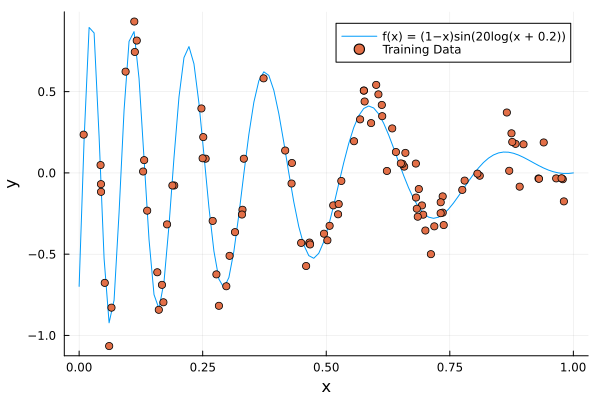

In [7]:
begin
	x_true = range(0, 1, 100)
	y_true = (1 .- x_true) .* sin.(20 .* log.(x_true .+ 0.2))
	p1 = plot(x_true, y_true; label="f(x) = (1−x)sin(20log(x + 0.2))", xlabel="x", ylabel="y")

	# Data generation
	# Each data entry should be its own column
	# Using Float32 is important as math will be faster compared to Float64
	n = 100
	x_data = rand(Float32, 1, n)
	y_data = (1 .- x_data) .* sin.(20 .* log.(x_data .+ 0.2)) + 0.1f0 * randn(Float32, 1, n)
	scatter!(p1, x_data[1,:], y_data[1,:]; label="Training Data", )
end

In [8]:
model, losses = train(x_data, y_data);

Epoch: 100, Loss: 0.13988541
Epoch: 200, Loss: 0.13988416
Epoch: 300, Loss: 0.13988285
Epoch: 400, Loss: 0.1398812
Epoch: 500, Loss: 0.13987914
Epoch: 600, Loss: 0.13987653
Epoch: 700, Loss: 0.13987298
Epoch: 800, Loss: 0.13986778
Epoch: 900, Loss: 0.13985926
Epoch: 1000, Loss: 0.1398433
Epoch: 1100, Loss: 0.13980885
Epoch: 1200, Loss: 0.13972339
Epoch: 1300, Loss: 0.13949606
Epoch: 1400, Loss: 0.13902462
Epoch: 1500, Loss: 0.13793385
Epoch: 1600, Loss: 0.13590273
Epoch: 1700, Loss: 0.13533652
Epoch: 1800, Loss: 0.1347647
Epoch: 1900, Loss: 0.13238613
Epoch: 2000, Loss: 0.12355524
Epoch: 2100, Loss: 0.11213101
Epoch: 2200, Loss: 0.10388239
Epoch: 2300, Loss: 0.09786171
Epoch: 2400, Loss: 0.09243913
Epoch: 2500, Loss: 0.087569594
Epoch: 2600, Loss: 0.083219185
Epoch: 2700, Loss: 0.07947748
Epoch: 2800, Loss: 0.07644522
Epoch: 2900, Loss: 0.07408061
Epoch: 3000, Loss: 0.071665436
Epoch: 3100, Loss: 0.06655528
Epoch: 3200, Loss: 0.055305384
Epoch: 3300, Loss: 0.04200876
Epoch: 3400, Loss:

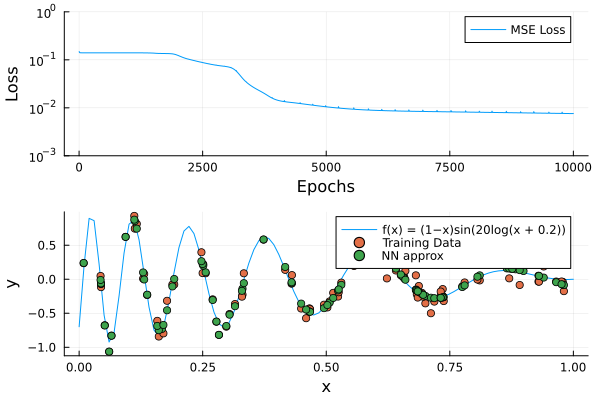

In [9]:
begin 
	# Plot Losses vs Epochs
	p2 = plot(losses; 
		label="MSE Loss", xlabel="Epochs", ylabel="Loss",yaxis=:log, ylims=(1e-3,1e0)
	)

	# Plot NN approximation vs true function/ data
	p3 = scatter(p1, x_data[1,:], model(x_data)[1,:]; label="NN approx")
	plot(p2, p3; layout=(2,1))
end

### Question 3: Car on Hill Challenge Problem

In [10]:
using CommonRLInterface
using CommonRLInterface.Wrappers: QuickWrapper

In [11]:
env = QuickWrapper(HW5.mc,
                   actions=[-1.0, -0.5, 0.0, 0.5, 1.0],
                   observe=mc->observe(mc)[1:2]
                  )

QuickWrapper{DMUStudent.HW5.MountainCar{Random.TaskLocalRNG}, @NamedTuple{actions::Vector{Float64}, observe::var"#22#23"}}(DMUStudent.HW5.MountainCar{Random.TaskLocalRNG}([-0.03300397177961112, 0.0], DMUStudent.HW5.Rect[DMUStudent.HW5.Rect(8, 8, 11, 4), DMUStudent.HW5.Rect(24, 8, 11, 4), DMUStudent.HW5.Rect(40, 8, 11, 4), DMUStudent.HW5.Rect(56, 8, 11, 4), DMUStudent.HW5.Rect(72, 8, 11, 4)], DMUStudent.HW5.Rect(42, 85, 15, 2), DMUStudent.HW5.Rect(20, 33, 1, 1), 5.0, (36.0, 500.0), false, Random.TaskLocalRNG()), (actions = [-1.0, -0.5, 0.0, 0.5, 1.0], observe = var"#22#23"()))

In [12]:
function dqn(env; max_steps = 100_000, γ=0.99, learning_rate=0.0005, fix_target_every=1000, eval_every=200)
    # This network should work for the Q function - an input is a state; the output is a vector containing the Q-values for each action 
    Q = Chain(Dense(2, 128, relu),
              #Dense(128, 128, tanh),
              Dense(128, length(actions(env))))

    opt = Flux.setup(ADAM(learning_rate), Q)

    # initialize the target Q network (Q_θ')
    Q_target = deepcopy(Q)
    Best_Q = deepcopy(Q)

    # ϵ-greedy policy (NOTE: scale later to become more greedy as training progresses)
    function ϵ_greedy_policy(env, s; ϵ=0.15)
        if rand() < ϵ
            return rand(1:length(actions(env)))
        else
            return argmax(a_ind->Q(s)[a_ind], 1:length(actions(env)))
        end
    end

    # Loss function for Q training
    function loss(Q, Q_target, s, a_ind, r, sp, done)
        if !done
            return (r + γ * maximum(Q_target(sp)) - Q(s)[a_ind])^2       
        else
            return (r - Q(s)[a_ind])^2
        end
            # NOTE: make sure to take care of cases when the problem has terminated correctly
    end

    # First step and experience tuple
    s = observe(env)
    a_ind = ϵ_greedy_policy(env, s) # action index - the index, rather than the actual action itself, will be needed in the loss function
    r = act!(env, actions(env)[a_ind])
    sp = observe(env)
    done = terminated(env)  # True or False
    experience_tuple = (s, a_ind, r, sp, done)

    # --- The Buffer ---
    # FIFO buffer of experience tuples (s, a_ind, r, sp, done)
    # experience is randomly sampled from the buffer, old experience eventually
    # replaced by new experience tuples
    buffer_length = 1000    # max length of the buffer
    buffer_index = 1        # index of last added experience tuple
    buffer = Vector{typeof(experience_tuple)}(undef, buffer_length)
    buffer[buffer_index] = experience_tuple

    max_score = -Inf
    scores = [max_score]
    best_scores = [max_score]
    
    # loop for n_episodes
    # "In reinforcement learning, an episode means a simulation of the environment from a start state 
    #  either to a terminal state or to a point where the algorithm decides to terminate because it 
    #  doesn't think there is any more useful information."


    steps = []
    for step in 1:max_steps
    
        # NOTE: after each time the environment reaches a terminal state, you need to reset it
        if done
            reset!(env)
        end

        # Act (make a step) on the environment and get the next experience tuple
        s = observe(env)
        ϵ = max(0.05, 1 - 10*step / max_steps) 
        a_ind = ϵ_greedy_policy(env, s, ϵ = ϵ) # action index - the index, rather than the actual action itself, will be needed in the loss function
        r = act!(env, actions(env)[a_ind])
        sp = observe(env)
        done = terminated(env)  # True or False
        experience_tuple = (s, a_ind, r, sp, done)
        step += 1
        
        # Add experience tuple to the FIFO buffer
        if buffer_index == buffer_length
            buffer_index = 0
        end
        buffer_index += 1
        buffer[buffer_index] = experience_tuple

        # select some data from the buffer
        num_training_tuples = 50 # number of training tuples to sample from the buffer
        if length(buffer) > num_training_tuples
            data = rand(buffer[1:buffer_index], 50)
            # Flux.Optimise.train!(loss, Q, data, opt)
            for tup in data
                loss_value, grads = Flux.withgradient(loss, Q, Q_target, tup...)
                Flux.update!(opt, Q, grads[1])
            end
        end

        # Update the fixed target Q network
        if step % fix_target_every == 0
            Q_target = deepcopy(Q)
        end

        # evaluate the current policy
        if step % eval_every == 0
            eval = HW5.evaluate(s->actions(env)[argmax(Q(s[1:2]))], n_episodes=100); # quick eval
            score = eval.score
            push!(steps, step)
            push!(scores, score)
            println("PROGRESS :: Steps Taken: $step, Score: $score")
            if score > max_score
                max_score = score
                Best_Q = deepcopy(Q)
                push!(best_scores, max_score)
                println("NEW MAXIMUM :: Max Score: $max_score, Steps Taken: $step")
            end
        end

    end

    # Make sure to evaluate, print, and plot often! You will want to save your best policy.

    println("Training Complete! Evaluating best Model")
    HW5.evaluate(s -> actions(env)[argmax(Best_Q(s[1:2]))], "calvin.henggeler@colorado.edu"; fname="best.json")
    
    return Best_Q, scores, steps
end

dqn (generic function with 1 method)

In [13]:
Q, scores, steps = dqn(env)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01

PROGRESS :: Steps Taken: 200, Score: -3.857408817266683
NEW MAXIMUM :: Max Score: -3.857408817266683, Steps Taken: 200



Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


PROGRESS :: Steps Taken: 400, Score: -3.857408817266683


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


...

PROGRESS :: Steps Taken: 99800, Score: 38.52638760602486


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00

PROGRESS :: Steps Taken: 100000, Score: 32.201312800704756
Training Complete! Evaluating best Model



Progress: 100%|█████████████████████████████████████████| Time: 0:00:25
┌ Info: Please submit best.json to gradescope.
└ @ DMUStudent.HW5 none:384


(Chain(Dense(2 => 128, relu), Dense(128 => 5)), [-Inf, -3.857408817266683, -3.857408817266683, -4.582608826471184, -3.6438132388516435, -3.857408817266683, -3.857408817266683, -3.857435248052339, -3.857408817266683, -3.871527651020521  …  37.962088246877855, 34.27208359780103, 32.26625748211019, 33.9061129581762, 33.23084902423174, 32.79615558805567, 33.17840593538711, 33.07195336599511, 38.52638760602486, 32.201312800704756], Any[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000  …  98200, 98400, 98600, 98800, 99000, 99200, 99400, 99600, 99800, 100000])

In [14]:
HW5.evaluate(s->actions(env)[argmax(Q(s[1:2]))],"calvin.henggeler@colorado.edu", fname="ReturnedQ.json") # Save model

Progress: 100%|█████████████████████████████████████████| Time: 0:00:25
┌ Info: Please submit ReturnedQ.json to gradescope.
└ @ DMUStudent.HW5 none:384


(assignment = "hw5", email = "calvin.henggeler@colorado.edu", score = 58.44268397659292, hash = "8d29358b6dd9be5444d56a727080f187be599b223616398bf123bcb3715c7dc8")

The algorithm I wrote is the DQN algorithm based off the provided starting code. The action is selected using a Epsilon-greedy policy with a declining explosion value as more steps are taken in the environment down to an arbitrarily written minimum value of 0.05. The Q model is a 2 layer neural network with a tanh activation function. Performance could be improved by changing the number of layers and the activation functions along with other hyperparameters.

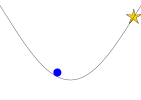

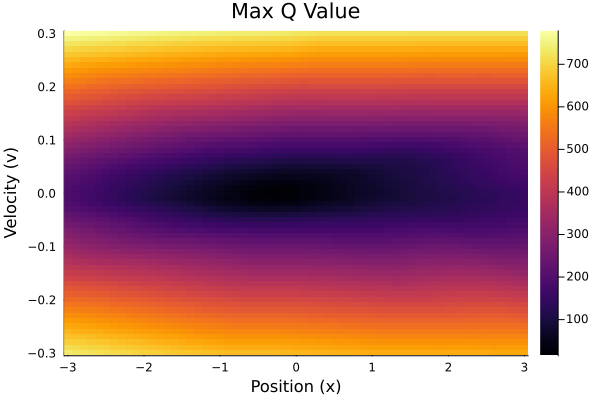

In [15]:
#----------
# Rendering
#----------

# You can show an image of the environment like this (use ElectronDisplay if running from REPL):
display(render(env))

# The following code allows you to render the value function
xs = -3.0f0:0.1f0:3.0f0
vs = -0.3f0:0.01f0:0.3f0
heatmap(xs, vs, (x, v) -> maximum(Q([x, v])), xlabel="Position (x)", ylabel="Velocity (v)", title="Max Q Value")



In [16]:
begin 
	# Plot score vs steps taken
	p1 = plot(steps, scores; 
		label=false, xlabel="Steps in Environment", ylabel="Score"
	)
end